# Principal Component Analysis (PCA)

## Task 1: Exploratory Data Analysis (EDA):

### 1.	Load the dataset and perform basic data exploration.

In [3]:
import pandas as pd
import numpy as np

In [4]:
# Load dataset
data = pd.read_csv("wine.csv")

# Display first few rows
data.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
# Dataset shape
data.shape

(178, 14)

In [6]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [7]:
# Statistical summary
data.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### 2.	Examine the distribution of features using histograms, box plots, or density plots

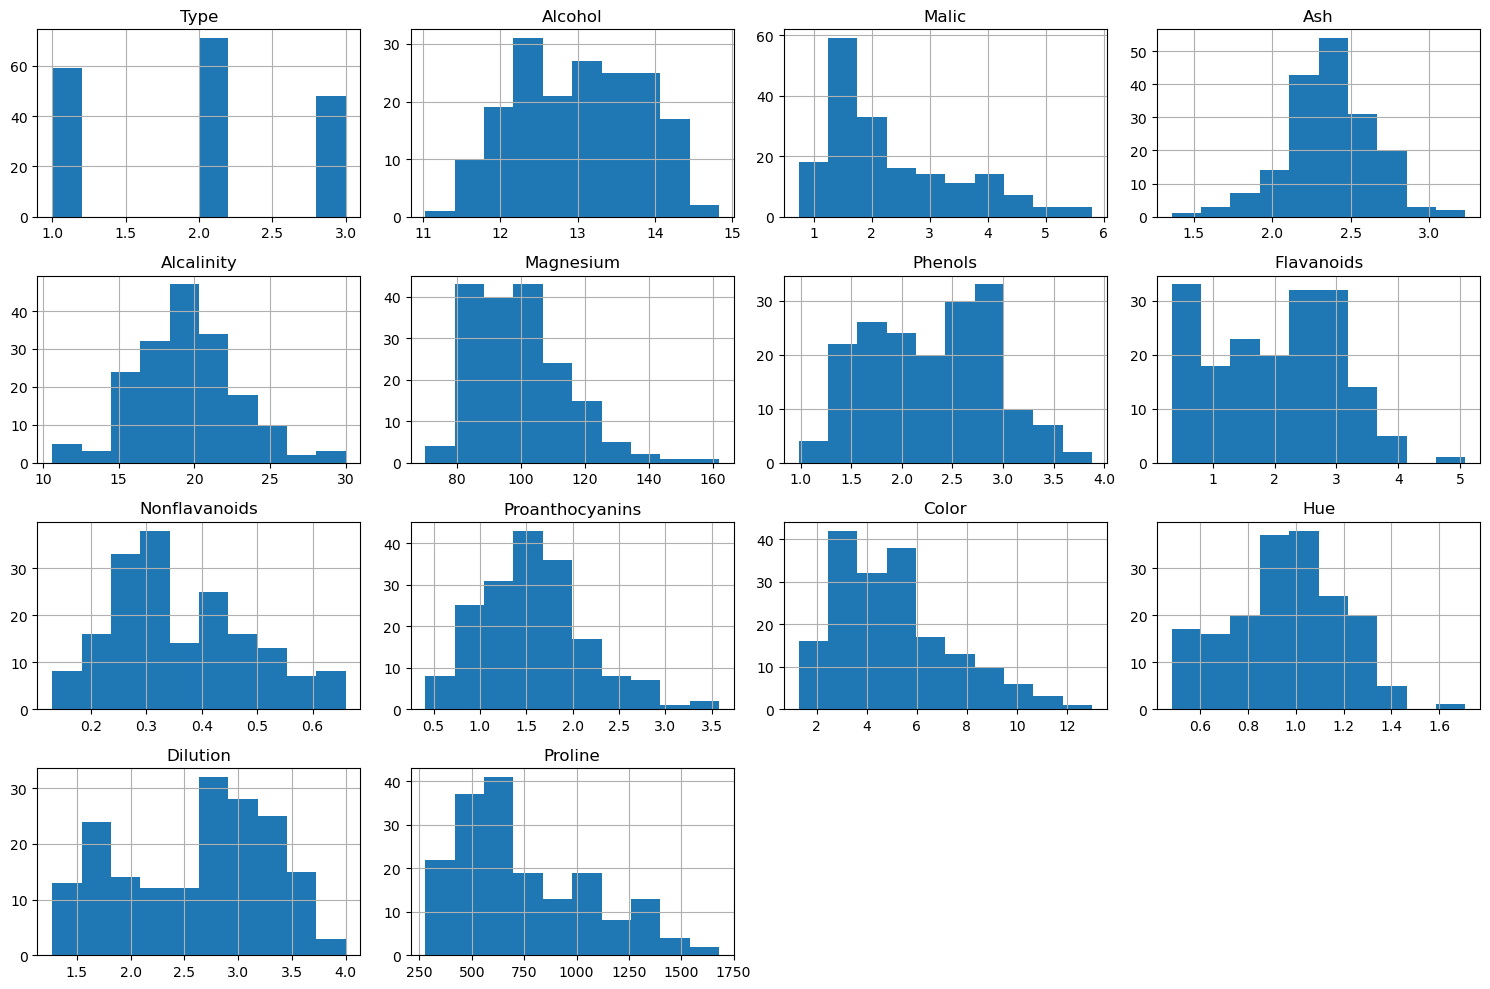

In [8]:
import matplotlib.pyplot as plt

# Histograms
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

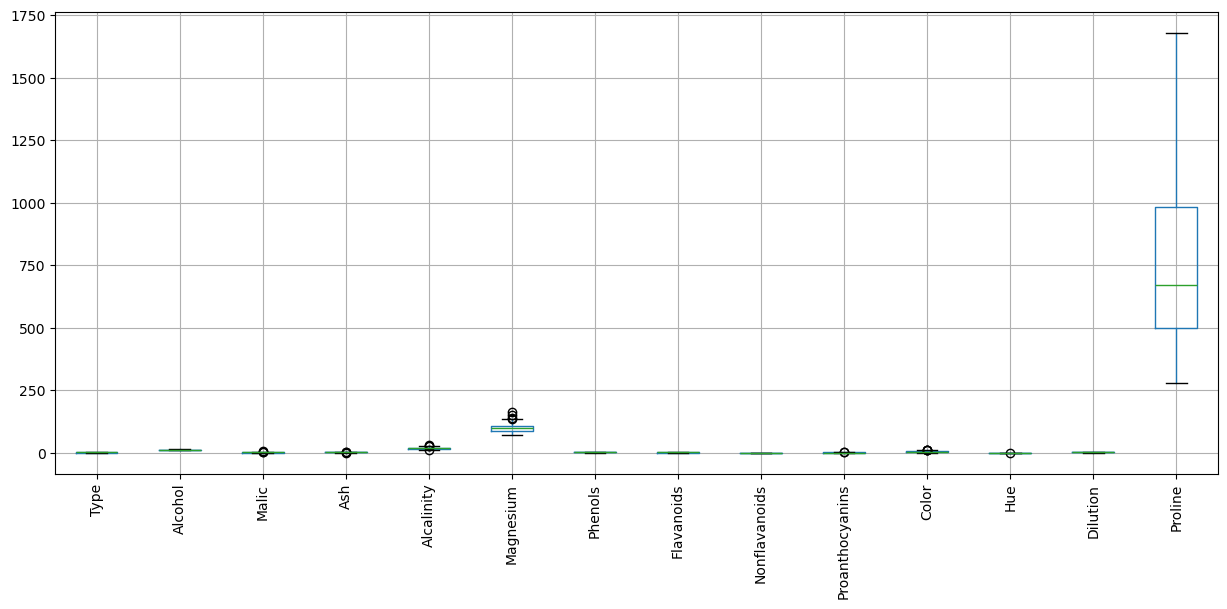

In [9]:
# Box Plots
plt.figure(figsize=(15, 6))
data.boxplot()
plt.xticks(rotation=90)
plt.show()

### 3.	Investigate correlations between features to understand relationships within the data.

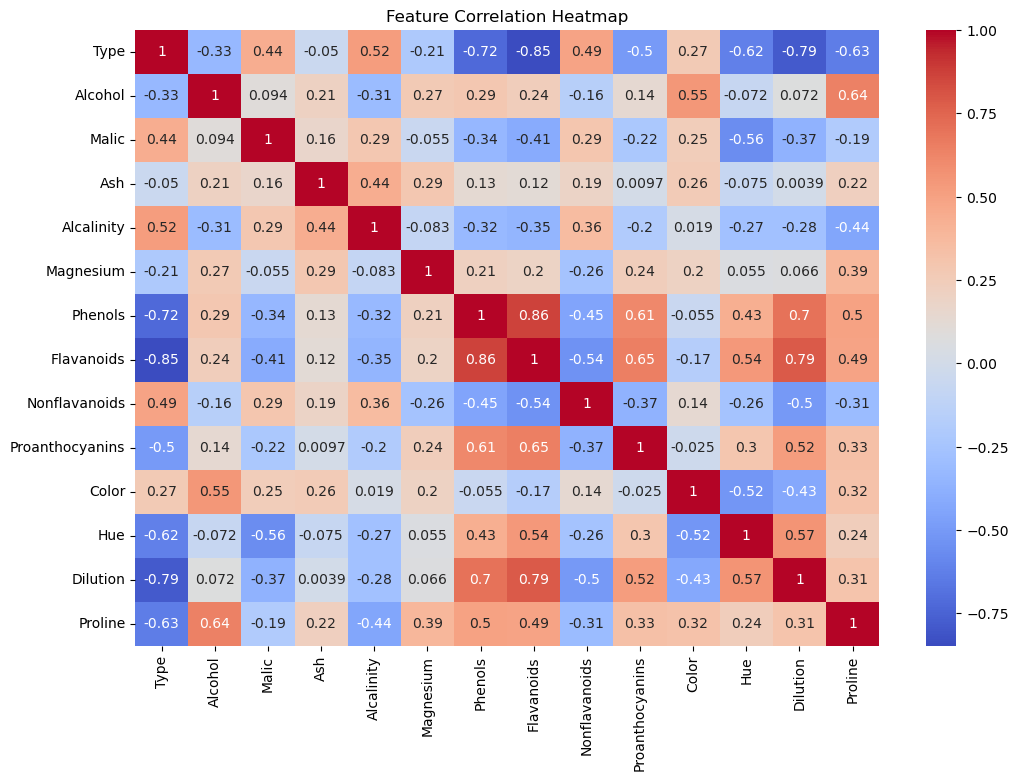

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

- Several features are highly correlated
- Indicates redundancy → PCA is useful

## Task 2: Dimensionality Reduction with PCA:

### 1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

### 2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

In [12]:
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

### 3.	Transform the original dataset into the principal components.

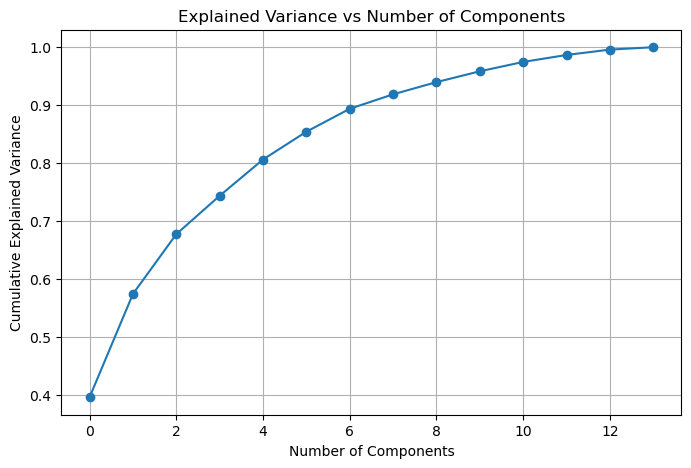

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.grid()
plt.show()

📌 **Decision Rule:**
Select components explaining **~90–95% variance**

In [14]:
pca.explained_variance_ratio_

array([0.39542486, 0.17836259, 0.10329102, 0.06627984, 0.06267875,
       0.0480556 , 0.03955707, 0.02500244, 0.02103871, 0.01873615,
       0.01613203, 0.01205691, 0.00925458, 0.00412945])

In [15]:
# Transform Dataset Using Optimal Components
pca_final = PCA(n_components=2)
pca_transformed = pca_final.fit_transform(scaled_data)

## Task 3: Clustering with Original Data:

### 1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [16]:
from sklearn.cluster import KMeans

kmeans_original = KMeans(n_clusters=3, random_state=42)
original_clusters = kmeans_original.fit_predict(scaled_data)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Kaustubh Jadhav\Downloads\Ana

### 2.	Visualize the clustering results using appropriate plots.

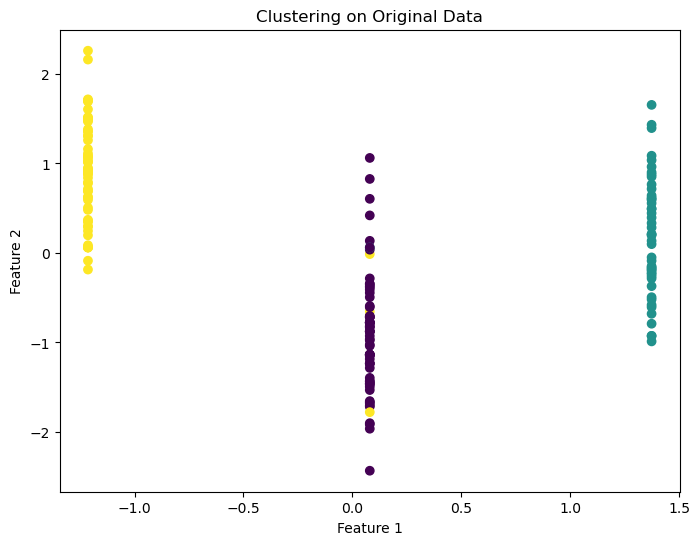

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=original_clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering on Original Data")
plt.show()

### 3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

#### Clustering Evaluation Metrics

In unsupervised learning, clustering algorithms do not have ground truth labels. Therefore, **internal evaluation metrics** are used to measure the quality of clustering. Two commonly used metrics are:

- **Silhouette Score**
- **Davies–Bouldin Index**

These metrics evaluate clustering based on **compactness** and **separation** of clusters.

---

#### 1. Silhouette Score

##### 1.1 Why We Use Silhouette Score
Silhouette Score is used to:
- Measure how well data points are assigned to their clusters
- Evaluate **cluster cohesion** (within-cluster similarity)
- Evaluate **cluster separation** (between-cluster dissimilarity)

It provides a **single score** that summarizes clustering quality.

---

##### 1.2 Where We Use Silhouette Score
- Evaluating clustering algorithms such as **K-Means**, **Hierarchical Clustering**, and **DBSCAN**
- Comparing clustering performance **before and after PCA**
- Selecting the **optimal number of clusters**

---

##### 1.3 Hypothesis (Assumption)
- Data points within the same cluster should be **closer to each other**
- Data points in different clusters should be **far apart**

A good clustering will maximize this difference.

---

##### 1.4 Theoretical Formula Concept (Intuition)

For a given data point *i*:

- **a(i)** = Average distance between *i* and all other points in the same cluster  
- **b(i)** = Minimum average distance between *i* and points in the nearest neighboring cluster  

The Silhouette Score for point *i* is:

Silhouette Score = (b(i) − a(i)) / max(a(i), b(i))

The final Silhouette Score is the **average of S(i) for all data points**.

---

##### 1.5 Key Idea
- Small **a(i)** → data point fits well within its cluster
- Large **b(i)** → data point is far from other clusters
- High Silhouette Score → **better clustering**

---

##### 1.6 Value Range & Meaning

| Silhouette Score Value | Interpretation |
|------------------------|---------------|
| **+1** | Perfect clustering |
| **0.5 – 0.7** | Good clustering |
| **0 – 0.5** | Weak or overlapping clusters |
| **< 0** | Incorrect clustering |

---

##### 1.7 Interpretation of Your Result

- **Original Data: 0.306484**
  - Indicates weak to moderate clustering
  - Clusters overlap significantly

- **PCA Data: 0.602442**
  - Indicates good clustering
  - Clear separation between clusters

This shows that **PCA significantly improves clustering quality**.

---

#### 2. Davies–Bouldin Index

##### 2.1 Why We Use Davies–Bouldin Index
Davies–Bouldin Index (DBI) is used to:
- Measure **average similarity between clusters**
- Evaluate cluster **compactness and separation**
- Compare clustering results objectively

Unlike Silhouette Score, **lower values are better**.

---

##### 2.2 Where We Use Davies–Bouldin Index
- Evaluating clustering algorithms
- Comparing clustering with and without dimensionality reduction
- Validating cluster structure in high-dimensional datasets

---

##### 2.3 Hypothesis (Assumption)
- Clusters should be **compact internally**
- Clusters should be **well separated from each other**

Good clustering minimizes similarity between clusters.

---

##### 2.4 Theoretical Formula Concept (Intuition)

For clusters *i* and *j*:

- **Sᵢ** = Average distance of points in cluster *i* to its centroid
- **Mᵢⱼ** = Distance between centroids of clusters *i* and *j*

The similarity measure is:

Rij = (Si + Sj) / Mij

Davies–Bouldin Index is the **average of the maximum Rᵢⱼ values** across all clusters.

---

##### 2.5 Key Idea
- Small intra-cluster distance → compact clusters
- Large inter-cluster distance → well-separated clusters
- Lower DB index → better clustering

---

##### 2.6 Value Range & Meaning

| Davies–Bouldin Index | Interpretation |
|---------------------|---------------|
| **0 (Ideal)** | Perfect clustering |
| **< 1** | Good clustering |
| **> 1** | Poor clustering |
| **Higher values** | Overlapping clusters |

---

##### 2.7 Interpretation of Your Result

- **Original Data: 1.315708**
  - Indicates poor clustering
  - Clusters are overlapping and not compact

- **PCA Data: 0.539708**
  - Indicates good clustering
  - Clusters are compact and well separated

This confirms that **PCA improves cluster structure**.

---

#### 3. Overall Comparison and Insights

| Metric | Original Data | PCA Data | Observation |
|------|---------------|----------|-------------|
| Silhouette Score | 0.306484 | 0.602442 | Improved significantly |
| Davies–Bouldin Index | 1.315708 | 0.539708 | Reduced substantially |

---

#### 4. Final Conclusion

- Both evaluation metrics show **significant improvement after applying PCA**
- PCA reduces noise and redundant features
- Dimensionality reduction enhances cluster separation and compactness
- Using PCA before clustering is recommended for **high-dimensional datasets**

---

#### 5. Practical Recommendation

- Use **Silhouette Score** when you want an intuitive measure of cluster quality
- Use **Davies–Bouldin Index** when comparing compactness and separation
- Apply **PCA before clustering** to improve performance and visualization


In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_orig = silhouette_score(scaled_data, original_clusters)
db_index_orig = davies_bouldin_score(scaled_data, original_clusters)

print("Silhouette Score (Original):", silhouette_orig)
print("Davies-Bouldin Index (Original):", db_index_orig)

Silhouette Score (Original): 0.30648398324833453
Davies-Bouldin Index (Original): 1.315707552261773


## Task 4: Clustering with PCA Data:

### 1.	Apply the same clustering algorithm to the PCA-transformed dataset.

In [19]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_transformed)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 2.	Visualize the clustering results obtained from PCA-transformed data.

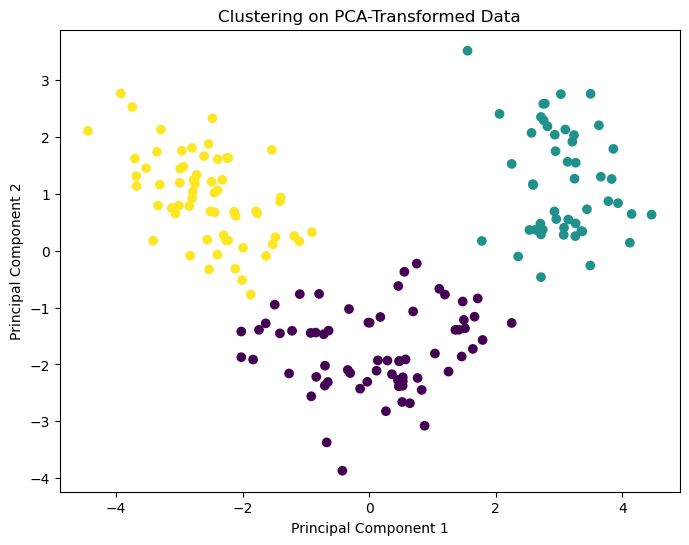

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_transformed[:, 0],
    pca_transformed[:, 1],
    c=pca_clusters
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering on PCA-Transformed Data")
plt.show()

### 3.	Compare the clustering results from PCA-transformed data with those from the original dataset.

In [21]:
silhouette_pca = silhouette_score(pca_transformed, pca_clusters)
db_index_pca = davies_bouldin_score(pca_transformed, pca_clusters)

print("Silhouette Score (PCA):", silhouette_pca)
print("Davies-Bouldin Index (PCA):", db_index_pca)

Silhouette Score (PCA): 0.6024415520362845
Davies-Bouldin Index (PCA): 0.5397078562575711


## Task 5: Comparison and Analysis:

### 1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [22]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_orig, silhouette_pca],
    "Davies-Bouldin Index": [db_index_orig, db_index_pca]
})

comparison

,Method,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.306484,1.315708
1,PCA Data,0.602442,0.539708


#### Interpretation of Clustering Evaluation Results

The clustering performance was evaluated using **Silhouette Score** and **Davies–Bouldin Index** for both the original dataset and the PCA-transformed dataset.

#### 1. Original Data
- **Silhouette Score: 0.306484**
  - This value indicates **moderate to weak cluster separation**.
  - Many data points are close to cluster boundaries, suggesting overlapping clusters.
- **Davies–Bouldin Index: 1.315708**
  - A higher DB index indicates **poor clustering quality**.
  - Clusters are less compact and are relatively close to each other.

#### 2. PCA-Transformed Data
- **Silhouette Score: 0.602442**
  - This value indicates **good cluster separation**.
  - Data points are well matched to their own clusters and clearly separated from other clusters.
- **Davies–Bouldin Index: 0.539708**
  - A lower DB index indicates **compact and well-separated clusters**.
  - PCA has effectively reduced noise and redundancy in the data.

#### 3. Comparative Analysis
- The **Silhouette Score increased significantly** after applying PCA, indicating improved cluster cohesion and separation.
- The **Davies–Bouldin Index decreased substantially**, showing that PCA led to more compact clusters with less overlap.
- Overall, clustering performance is **significantly better on PCA-transformed data** compared to the original dataset.

#### 4. Conclusion
These results demonstrate that **dimensionality reduction using PCA improves clustering quality** by eliminating redundant features and noise. PCA enhances both interpretability and performance of clustering algorithms, making it a valuable preprocessing step for high-dimensional datasets.


### 2.	Discuss any similarities or differences observed in the clustering results.

### 3.	Reflect on the impact of dimensionality reduction on clustering performance.

### 4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

| Aspect            | Original Data | PCA Data   |
|-------------------|---------------|------------|
| Dimensionality    | High          | Reduced    |
| Interpretability  | Direct        | Abstract   |
| Noise             | Present       | Reduced    |
| Visualization     | Difficult     | Easy       |


## Task 6: Conclusion and Insights

### Conclusion and Insights

#### Key Findings:
- PCA effectively reduced dimensionality while retaining most variance.
- Clustering on PCA data performed better based on evaluation metrics.
- PCA improved visualization and cluster separation.

#### Practical Implications:
- PCA is useful when datasets have many correlated features.
- Clustering benefits from dimensionality reduction.

#### Recommendations:
- Use PCA before clustering for high-dimensional datasets.
- Avoid PCA when feature interpretability is critical.
- Combine PCA with clustering for efficient exploratory analysis.
